# 01. 탐색적 데이터 분석 (EDA)

WM-811K 데이터셋의 구조/분포를 파악하고 결함 패턴별 대표 샘플을 시각화합니다.

**목표:**
- 라벨링된 샘플 수와 클래스별 분포 확인
- 웨이퍼 맵 크기(die count) 분포 파악
- 각 결함 패턴의 시각적 특성 이해
- 학습에 쓸 하위셋 정의

**일정:** 1~2주차


## 1. 환경 및 데이터 로드

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

PKL_PATH = Path(r"C:\Users\ParkJunbeom\내 드라이브(yrtny70127@gmail.com)\Colab Notebooks\Github\Wafer_Analyze\data\LSWMD.pkl")  
assert PKL_PATH.exists(), f"파일 없음: {PKL_PATH.resolve()}"

# 00_test_load_pkl.ipynb에서 이미 검증된 로더
df = pd.read_pickle(PKL_PATH)
print(f"shape: {df.shape}")
df.head(3)


shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]


In [6]:
# 한글 폰트 설정 (matplotlib)
import sys
from pathlib import Path

# notebooks/ 에서 실행 중이면 상위 폴더를 import path에 추가
_root = Path.cwd()
if _root.name == "notebooks":
    sys.path.insert(0, str(_root.parent))

from utils.korean_font import set_korean_font
set_korean_font()

[korean_font] 'Malgun Gothic' 적용 완료 (axes.unicode_minus=False)


'Malgun Gothic'

## 2. 라벨 정규화 및 기본 통계

`failureType`은 타입이 혼재(문자열/중첩배열)되어 있어 먼저 정리합니다.

In [2]:
def normalize_label(x):
    if isinstance(x, str):
        return x if x else 'none'
    if hasattr(x, '__len__') and not isinstance(x, str):
        if len(x) == 0:
            return 'unlabeled'
        first = x
        while hasattr(first, '__len__') and not isinstance(first, str):
            if len(first) == 0:
                return 'unlabeled'
            first = first[0]
        return str(first) if first else 'none'
    return 'unlabeled'

df['label'] = df['failureType'].map(normalize_label)
df['split'] = df['trianTestLabel'].map(normalize_label) if 'trianTestLabel' in df.columns else 'unlabeled'

print(df['label'].value_counts())
print("\n---\n")
print(df['split'].value_counts())


label
unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

---

split
unlabeled    638507
Test         118595
Training      54355
Name: count, dtype: int64


## 3. 클래스 분포 시각화

**체크포인트:** 라벨링된 샘플은 전체의 ~21%이고, `none`이 압도적으로 많으며 실제 결함 클래스는 심한 불균형입니다 (예: Near-full은 수백 장, none은 수만 장). 학습 시 class weighting이나 오버샘플링 필수.

라벨링된 샘플: 172,950장 (21.3%)


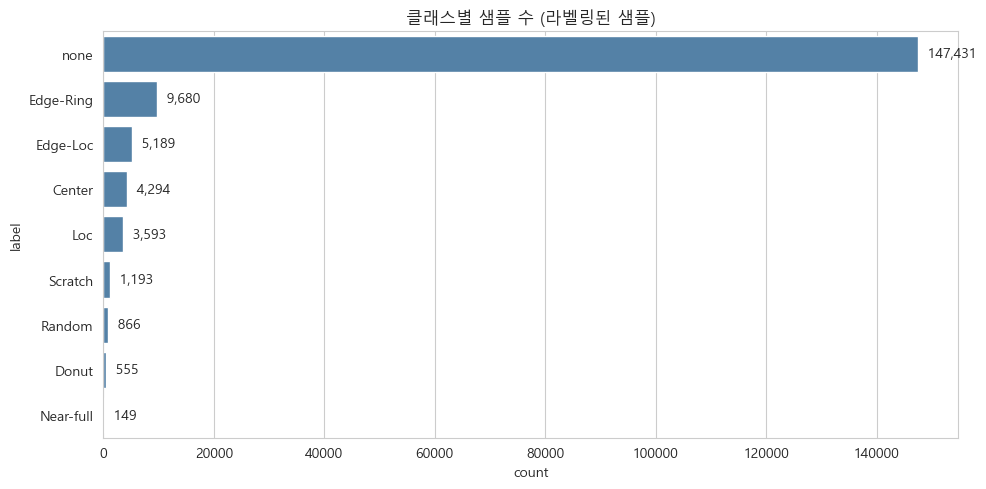

In [7]:
labeled = df[df['label'] != 'unlabeled'].copy()
print(f"라벨링된 샘플: {len(labeled):,}장 ({len(labeled)/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
order = labeled['label'].value_counts().index
sns.countplot(data=labeled, y='label', order=order, ax=ax, color='steelblue')
ax.set_title('클래스별 샘플 수 (라벨링된 샘플)')
for i, cnt in enumerate(labeled['label'].value_counts().values):
    ax.text(cnt, i, f'  {cnt:,}', va='center')
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. 웨이퍼 맵 크기 분포

웨이퍼 크기 (H x W) 상위 10가지 조합:
wafer_h  wafer_w
25       27         18781
26       26         14366
30       34         12400
29       26         11751
27       25         10682
39       37         10173
33       29          8125
42       44          6724
44       41          6134
41       33          5091
dtype: int64


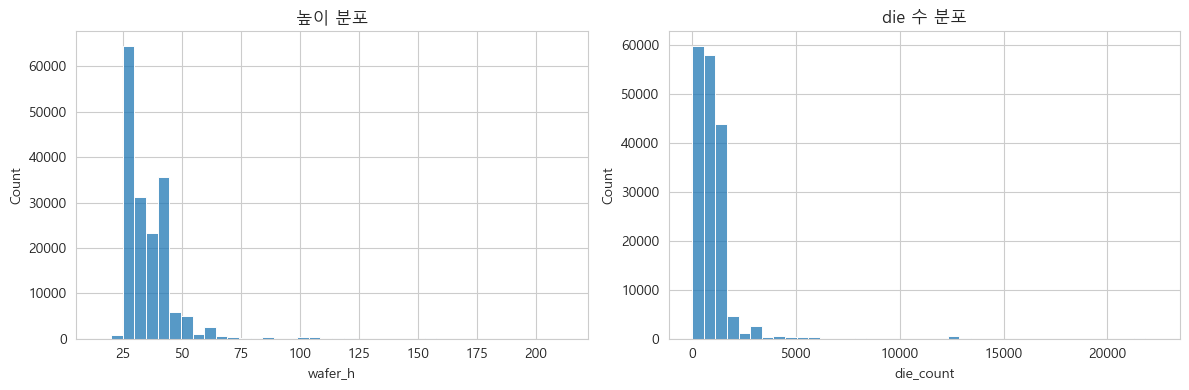

In [8]:
labeled['wafer_h'] = labeled['waferMap'].map(lambda m: m.shape[0])
labeled['wafer_w'] = labeled['waferMap'].map(lambda m: m.shape[1])
labeled['die_count'] = labeled['waferMap'].map(lambda m: (m > 0).sum())

print("웨이퍼 크기 (H x W) 상위 10가지 조합:")
size_counts = labeled.groupby(['wafer_h', 'wafer_w']).size().sort_values(ascending=False)
print(size_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(labeled['wafer_h'], bins=40, ax=axes[0]); axes[0].set_title('높이 분포')
sns.histplot(labeled['die_count'], bins=40, ax=axes[1]); axes[1].set_title('die 수 분포')
plt.tight_layout(); plt.show()


## 5. 클래스별 대표 샘플 시각화

각 결함 패턴이 어떻게 생겼는지 눈으로 확인해둡니다. 컬러맵:
- 0 (검정): 미검사 영역
- 1 (회색): 정상 다이
- 2 (빨강): 불량 다이

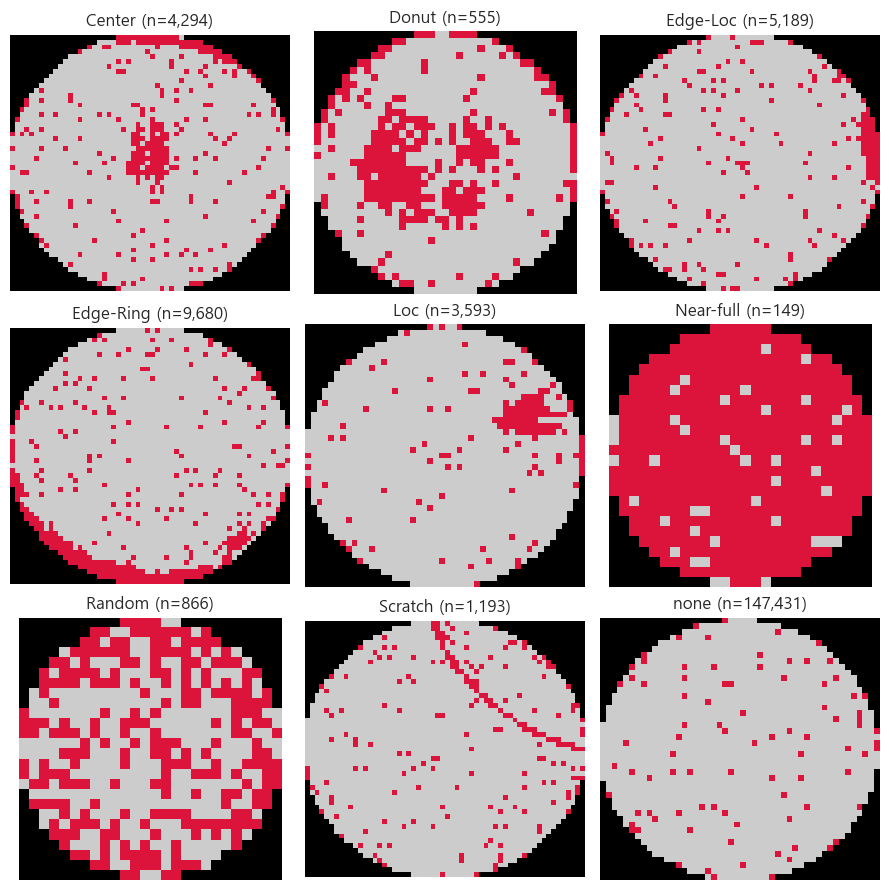

In [9]:
from matplotlib.colors import ListedColormap

CMAP = ListedColormap(['black', '#cccccc', 'crimson'])

classes = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
           'Loc', 'Near-full', 'Random', 'Scratch', 'none']

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, cls in zip(axes.flat, classes):
    subset = labeled[labeled['label'] == cls]
    if len(subset) == 0:
        ax.axis('off'); ax.set_title(f'{cls} (0)'); continue
    wmap = subset.iloc[0]['waferMap']
    ax.imshow(wmap, cmap=CMAP, vmin=0, vmax=2)
    ax.set_title(f'{cls} (n={len(subset):,})')
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results/figures/class_samples.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. 학습 대상 하위셋 정의 및 저장

라벨링된 샘플 + 웨이퍼 크기 필터링 후 `data/processed/labeled_index.parquet`로 저장.
전체 pkl 다시 안 읽도록 인덱스만 따로 보관.

In [10]:
# 너무 작거나 너무 큰 웨이퍼는 제외 (선택적)
SIZE_MIN = 20
SIZE_MAX = 200
filtered = labeled[
    (labeled['wafer_h'].between(SIZE_MIN, SIZE_MAX)) &
    (labeled['wafer_w'].between(SIZE_MIN, SIZE_MAX))
].copy()
print(f"필터 후: {len(filtered):,}장")
print(filtered['label'].value_counts())

# 인덱스만 저장 (waferMap은 02_preprocessing.ipynb에서 리사이즈 후 npz로)
out_path = Path('../data/processed/labeled_index.parquet')
out_path.parent.mkdir(parents=True, exist_ok=True)
meta = filtered[['label', 'split', 'wafer_h', 'wafer_w', 'die_count']].reset_index()
meta.to_parquet(out_path)
print(f"저장: {out_path}")


필터 후: 172,930장
label
none         147425
Edge-Ring      9677
Edge-Loc       5189
Center         4292
Loc            3588
Scratch        1190
Random          865
Donut           555
Near-full       149
Name: count, dtype: int64
저장: ..\data\processed\labeled_index.parquet


## 다음 단계

- `02_preprocessing.ipynb`: 웨이퍼 맵을 128x128로 리사이즈 → `.npz` 저장
- 클래스 불균형 대응 방식 결정 (weighted sampler vs oversampling)
